**Caso: Diagnostico Medico con escasez de expertos (Label Propagation)**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn import datasets
from sklearn.semi_supervised import LabelPropagation
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report

In [8]:
def lab_diagnostico_medico():
  """
  Simular la propagacion de etiquetas en un entorno de diagnostico medico
  donde el 95% de datos carecen carecen de etiquetas
  """

  # Carga de datos
  data_cancer = datasets.load_breast_cancer()
  X = data_cancer.data
  y = data_cancer.target

  # Simulacion: Ocultar el 95% de las etiquetas
  rng = np.random.RandomState(42)
  random_unlabeled_points = rng.rand(len(y)) < 0.95
  y_train = np.copy(y)
  y_train[random_unlabeled_points] = -1

  # Modelo: Label Propagation
  lp_model = LabelPropagation(kernel='rbf', gamma=0.01)
  lp_model.fit(X, y_train)

  # Visualizacion
  pca = PCA(n_components=2)
  X_viz = pca.fit_transform(X)

  plt.figure(figsize=(10,6))
  plt.scatter(X_viz[y_train != -1, 0], X_viz[y_train != -1, 1],
              c=y_train[y_train != -1], cmap='RdYlGn', s=100, edgecolors='k', label='Originales Etiquetados')
  plt.scatter(X_viz[y_train == -1, 0], X_viz[y_train == -1, 1],
              c=lp_model.transduction_[y_train==-1], cmap='RdYlGn', marker='.', alpha=0.3, label='Propagados')

  plt.title("Caso: Propagacion de etiquetas en un entorno de diagnostico medico")
  plt.legend()
  plt.show()

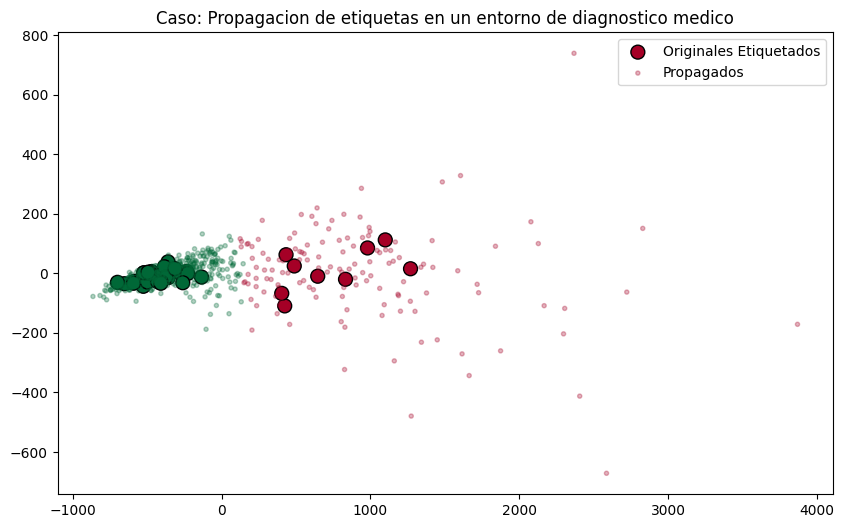

In [9]:
lab_diagnostico_medico()